# EDA for OilSlick Sentinel-1 GeoTIFF Data

# What's needed

- After running the notebook:
    - We need to save the filtered data splits as CSVs to ensure proper imagery use in the training pipeline
    - Include more information in ODE report

In [1]:
from pathlib import Path

import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
import folium

from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['image.cmap'] = 'viridis'

## Load metadata

The dataset is situated in `waterbench_data/data/OilSlick`. The metadata table stores relative paths for the GeoTIFFs used.

In [2]:
BASE_DIR = Path('../10_waterbench_data/data/OilSlick').resolve()
METADATA_PATH = BASE_DIR / 'metadata.csv'

print('Using dataset root:', BASE_DIR)

df = pd.read_csv(METADATA_PATH)
df['label_name'] = df['label'].map({0: 'negative', 1: 'positive'})
df[['sample_id', 'label_name', 'subcategory', 'image_path', 'n_bands']].head()

Using dataset root: C:\Users\vishn\AS-SS2026-Oil-Slick-Detection\10_waterbench_data\data\OilSlick


,sample_id,label_name,subcategory,image_path,n_bands
0,pos_00001,positive,Ships,images/positive/pos_00001.tif,12
1,pos_00007,positive,Ships,images/positive/pos_00007.tif,12
2,pos_00013,positive,Platforms,images/positive/pos_00013.tif,12
3,pos_00017,positive,Ships,images/positive/pos_00017.tif,12
4,pos_00022,positive,Ships,images/positive/pos_00022.tif,12


In [3]:
print(f'Samples: {len(df):,}')
print('Columns:', ', '.join(df.columns))
print()
display(df[['label_name', 'subcategory','nodata_fraction', 'is_valid', 'n_bands']].value_counts().rename('count').reset_index().head(20))

Samples: 1,363
Columns: sample_id, label, subcategory, source_date, center_lon, center_lat, date_diff_days, nodata_fraction, is_valid, image_path, rgb_path, swir_path, n_bands, band_order, scene_id, scene_datetime, platform, cloud_cover, sun_azimuth, sun_elevation, proj_epsg, reflectance_min, reflectance_max, reflectance_mean, label_name



,label_name,subcategory,nodata_fraction,is_valid,n_bands,count
0,negative,Negative,0.000000,True,12,602
1,positive,Ships,0.000000,True,12,410
2,positive,Natural seeps,0.000000,True,12,227
3,positive,Platforms,0.000000,True,12,64
4,negative,Negative,0.012695,True,12,2
5,positive,Natural seeps,0.000977,True,12,2
6,positive,Ships,0.077168,True,12,1
7,positive,Natural seeps,0.098633,True,12,1
8,positive,Natural seeps,0.041992,True,12,1
9,positive,Ships,0.021484,True,12,1


Since the `nodata_fraction` column is computed from the pixel values of Sentinel-2 imagery, it is not directly applicable to the Sentinel-1 data used in the project. Therefore, the nodata will be calculated based on the pixel values of the Sentinel-1 GeoTIFFs. By this, we can filter out files with too little valid data to ensure suitable quality for training our models.

## Data & Spatial Distributions

The overall label and subcategory distribution will be shown. Moreover, a spatial distribution of the samples will be visualized on a map.

C:\Users\vishn\AppData\Local\Temp\ipykernel_30784\1431750258.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Negative', 'Positive'])


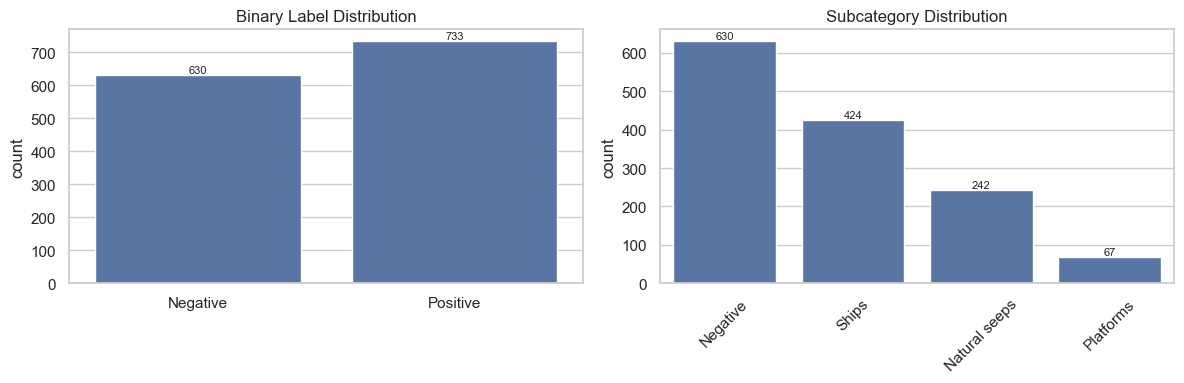

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='label_name', ax=axes[0], order=['negative', 'positive'])
axes[0].set_title('Binary Label Distribution')
axes[0].set_xlabel('')
axes[0].set_xticklabels(['Negative', 'Positive'])

sns.countplot(data=df, x='subcategory', ax=axes[1], order=df['subcategory'].value_counts().index)
axes[1].set_title('Subcategory Distribution')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

for p in axes[0].patches:
    height = p.get_height()
    axes[0].text(p.get_x() + p.get_width()/2., height,
                 '{:1.0f}'.format(height), ha="center", va='bottom', fontsize=8)

for p in axes[1].patches:
    height = p.get_height()
    axes[1].text(p.get_x() + p.get_width()/2., height,
                 '{:1.0f}'.format(height), ha="center", va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [5]:
subcategory_colors = {
    'Ships': '#FF0000',
    'Platforms': '#FF6B00',
    'Natural seeps': '#00AA00',
    'Negative': '#0066FF'
}

print("Subcategory color mapping:")
print("\033[91m● Ships\033[0m")
print("\033[33m● Platforms\033[0m")
print("\033[92m● Natural seeps\033[0m")
print("\033[94m● Negative\033[0m")
print("The circles are also clickable, showing the sample ID and label details.")

center_lat = df['center_lat'].mean()
center_lon = df['center_lon'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=2)

for _, row in df.iterrows():
    if row['label'] == 1:
        color = subcategory_colors.get(row['subcategory'])
        radius = 4
    else:
        color = subcategory_colors['Negative']
        radius = 3
    
    folium.CircleMarker(
        location=[row['center_lat'], row['center_lon']],
        radius=radius,
        color=color,
        fill=False,
        fillColor=color,
        fillOpacity=0.5,
        weight=1,
        popup=f"{row['sample_id']} ({row['label_name']}: {row['subcategory']})"
    ).add_to(m)

m

Subcategory color mapping:
● Ships
● Platforms
● Natural seeps
● Negative
The circles are also clickable, showing the sample ID and label details.


## GeoTIFF helpers

The GeoTIFFs are multi-band images. The VV and VH bands are the first two bands, and these need to be normalized using percentile clipping, taking the mean/std values calculated in "Optional Code: Compute mean / std for normalization" and z-score calculations to be visualized properly.

In [6]:
def get_img_path(relative_path: str) -> Path:
    p = Path(relative_path)
    filename = p.name if p.stem.endswith('_s1') else f"{p.stem}_s1{p.suffix}"
    return BASE_DIR / 'images_s1' / filename

def plot_geotiff(sample_row, ax, title, band=1, mean=None, std=None):
    path = get_img_path(sample_row['image_path'])
    
    with rasterio.open(path) as src:
        arr = src.read()
    
    nodata = (arr <= -50) | np.isnan(arr)
    valid = ~nodata.any(axis=0)
    
    image = arr[band].astype(float).copy()
    
    valid_pixels = image[valid]
    
    if len(valid_pixels) == 0:
        ax.imshow(np.zeros_like(image), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        ax.set_title(title)
        return
    
    p_low = np.percentile(valid_pixels, 2)
    p_high = np.percentile(valid_pixels, 98)
    image[valid] = np.clip(image[valid], p_low, p_high)
    
    if mean is not None and std is not None:
        image[valid] = (image[valid] - mean[band]) / (std[band] + 1e-6)
    else:
        raise ValueError("Mean and std must be provided for normalization.")
    
    image_norm = np.full_like(image, np.nan)
    norm_min = image[valid].min()
    norm_max = image[valid].max()
    image_norm[valid] = (image[valid] - norm_min) / (norm_max - norm_min + 1e-6)

    ax.imshow(image_norm, cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
    ax.set_title(title)

## Value Range Analysis

The following provides a function for calculating statistics (mean, std, median, percentiles, ...) for VV and VH channels on a given dataframe. First, we will collect valid pixels for each band across the whole dataset, and then compute the statistics on these pixels. This function will also be used to compute the mean and std values for train-set-based normalization.

Later on, frequency distributions for both VV and VH channels will be plotted.

In [7]:
def compute_stats(df, bands=[0, 1]):
    device = "cpu"
    print(f"Using: {device.upper()}")
    
    acc = {b: {
        'count': 0,
        'sum': torch.tensor(0.0, device=device),
        'sum_sq': torch.tensor(0.0, device=device),
        'min': torch.tensor(float('inf'), device=device),
        'max': torch.tensor(float('-inf'), device=device),
        'sample': []
    } for b in bands}
    
    SAMPLE_MAX = 50_000_000
    
    for idx, (_, row) in enumerate(df.iterrows()):
        path = get_img_path(row['image_path'])
        if path is None or not path.exists():
            continue
        
        try:
            with rasterio.open(path) as src:
                arr = src.read()
            
            nodata = (arr <= -50) | np.isnan(arr)
            valid = ~nodata.any(axis=0)
            
            for band in bands:
                img_band = arr[band].astype(np.float32)
                px = torch.from_numpy(img_band[valid].flatten()).to(device)
                
                if len(px) == 0:
                    continue
                
                acc[band]['count'] += len(px)
                acc[band]['sum'] += px.sum()
                acc[band]['sum_sq'] += (px ** 2).sum()
                acc[band]['min'] = torch.min(acc[band]['min'], px.min())
                acc[band]['max'] = torch.max(acc[band]['max'], px.max())
                
                if len(acc[band]['sample']) < SAMPLE_MAX:
                    acc[band]['sample'].extend(px.cpu().numpy())
        except Exception:
            continue
        
        if (idx + 1) % 100 == 0:
            print(f"  Processed: {idx+1}/{len(df)}")
    
    stats = {}
    band_names = {0: 'VV', 1: 'VH'}
    all_px = {}
    
    for band in bands:
        a = acc[band]
        if a['count'] == 0:
            continue
        
        count = a['count']
        mean = (a['sum'] / count).item()
        var = (a['sum_sq'] / count).item() - (mean ** 2)
        std = np.sqrt(max(var, 0))
        
        sample_arr = np.array(a['sample'][:SAMPLE_MAX], dtype=np.float32)
        
        stats[band] = {
            'count': count,
            'mean': mean,
            'std': std,
            'min': a['min'].item(),
            'max': a['max'].item(),
            'median': np.median(sample_arr),
            'p1': np.percentile(sample_arr, 1),
            'p5': np.percentile(sample_arr, 5),
            'p25': np.percentile(sample_arr, 25),
            'p50': np.percentile(sample_arr, 50),
            'p75': np.percentile(sample_arr, 75),
            'p95': np.percentile(sample_arr, 95),
            'p99': np.percentile(sample_arr, 99),
        }
        
        all_px[band] = sample_arr
    
    return stats, all_px, band_names

In [8]:
print("Computing statistics...")
stats, all_px, band_names = compute_stats(df, bands=[0, 1])

stats_df = pd.DataFrame(stats).T
stats_df.index = [band_names[i] for i in stats_df.index]
stats_df = stats_df.round(2)

print("\nComputed Statistics:")
display(stats_df)

Computing statistics...
Using: CPU
  Processed: 100/1363
  Processed: 200/1363
  Processed: 300/1363
  Processed: 400/1363
  Processed: 500/1363
  Processed: 600/1363
  Processed: 700/1363
  Processed: 800/1363
  Processed: 900/1363
  Processed: 1000/1363
  Processed: 1100/1363
  Processed: 1200/1363
  Processed: 1300/1363

Computed Statistics:


,count,mean,std,min,max,median,p1,p5,p25,p50,p75,p95,p99
VV,1.340655e+09,-17.24,24.17,-47.75,21936.06,-27.01,-36.34,-33.75,-29.92,-27.01,0.0,41.23,80.35
VH,1.340655e+09,-24.26,19.72,-49.77,1511.14,-33.16,-40.41,-38.65,-35.64,-33.16,0.0,21.14,29.51


These value ranges can be visualized as histograms / boxplots as follows:

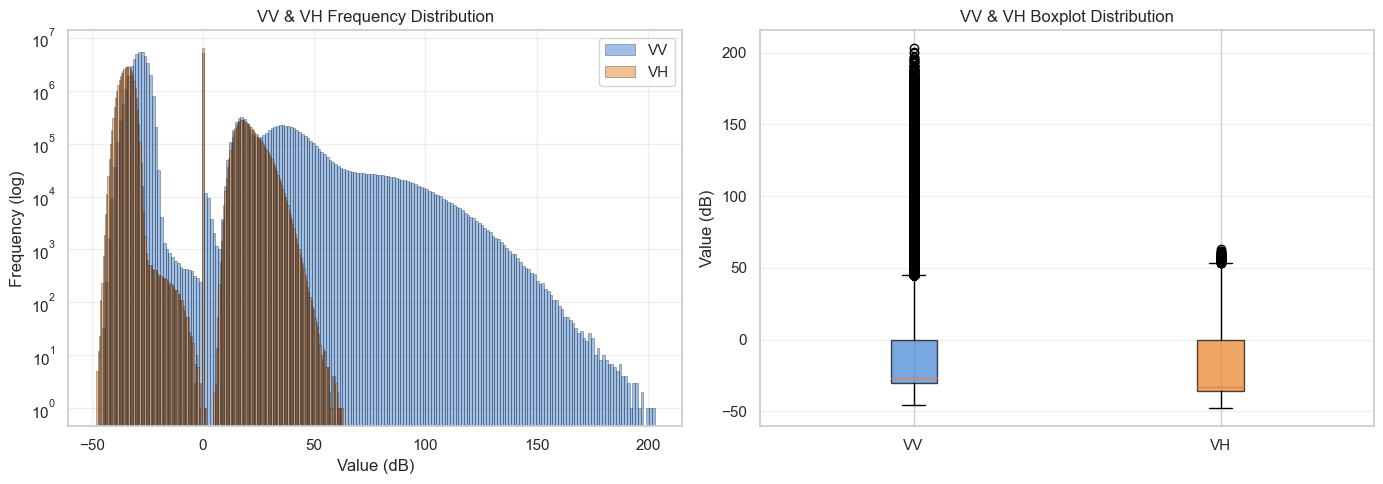

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = ["#4183d5", "#e97f23"]
for band in [0, 1]:
    pixels = all_px[band]
    ax.hist(pixels, bins=200, alpha=0.5, label=band_names[band], color=colors[band], edgecolor='black', linewidth=0.4)

ax.set_yscale('log')
ax.set_xlabel('Value (dB)')
ax.set_ylabel('Frequency (log)')
ax.set_title('VV & VH Frequency Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

ax_box = axes[1]
bp = ax_box.boxplot([all_px[0], all_px[1]], tick_labels=['VV', 'VH'], patch_artist=True)
for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
ax_box.set_ylabel('Value (dB)')
ax_box.set_title('VV & VH Boxplot Distribution')
ax_box.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Nodata Calculation and Threshold-based Filtering

If a TIFF file contains a high percentage of nodata pixels (e.g. >=40%), it may not provide useful information for training the model. Therefore, we will compute the nodata fraction instead of relying on the existing `nodata_fraction` CSV column for Sentinel-2, which does not cover the Sentinel-1 data. In addition, several TIFF files are corrupted, visible by calculating the images' std values, which are zero. These files will also be filtered out.

In [10]:
def check_validity(image_path, threshold, min_std=0.01):
    path = get_img_path(image_path)
    if path is None or not path.exists():
        return None, False
    
    try:
        with rasterio.open(path) as src:
            arr = src.read()
        
        nodata = (arr <= -50) | np.isnan(arr)
        valid = ~nodata.any(axis=0)
        n_valid = valid.sum()
        n_total = arr.shape[1] * arr.shape[2]
        nodata_frac = 1.0 - (n_valid / n_total)
        
        if nodata_frac > threshold:
            return nodata_frac, False
        
        for band in range(arr.shape[0]):
            img_band = arr[band].astype(np.float32)
            valid_pixels = img_band[valid]
            
            if len(valid_pixels) > 0 and valid_pixels.std() > min_std:
                return nodata_frac, True
        
        return nodata_frac, False
    except Exception:
        return None, False

In [11]:
NODATA_THRESH = 0.4

print("Computing nodata fractions and checking for valid samples...")
result = df['image_path'].apply(lambda x: check_validity(x, threshold=NODATA_THRESH))
df['nodata_frac'] = result.apply(lambda x: x[0])
df['valid_sample'] = result.apply(lambda x: x[1])

failed_nodata = df['nodata_frac'] <= NODATA_THRESH
failed_std = failed_nodata & ~df['valid_sample']

Computing nodata fractions and checking for valid samples...



After Filtering with 40% Nodata Threshold
Total: 1363
Valid: 1196 (87.7%)
Removed: 167 (12.3%)
Samples that failed nodata check: 97
Samples that failed std check: 70


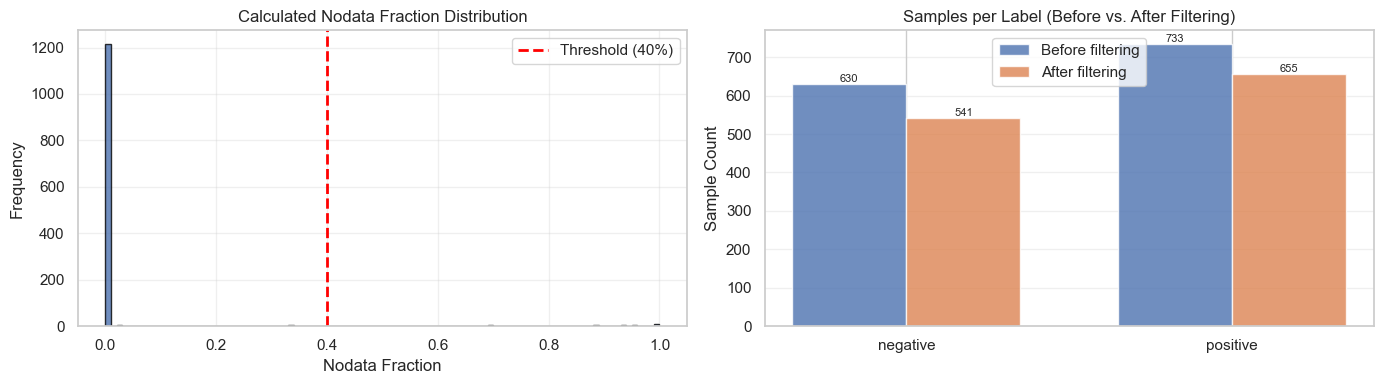

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(df['nodata_frac'].dropna(), bins=100, edgecolor='black', alpha=0.8)
ax.axvline(NODATA_THRESH, color='red', linestyle='--', linewidth=2, label='Threshold (40%)')
ax.set_xlabel('Nodata Fraction')
ax.set_ylabel('Frequency')
ax.set_title('Calculated Nodata Fraction Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

n_total = len(df)
n_valid = df['valid_sample'].sum()
n_removed = n_total - n_valid

print(f"\nAfter Filtering with {NODATA_THRESH*100:.0f}% Nodata Threshold")
print(f"Total: {n_total}")
print(f"Valid: {n_valid} ({n_valid/n_total*100:.1f}%)")
print(f"Removed: {n_removed} ({n_removed/n_total*100:.1f}%)")
print(f"Samples that failed nodata check: {(~failed_nodata).sum()}")
print(f"Samples that failed std check: {failed_std.sum()}")

ax = axes[1]
counts_before = df.groupby('label_name').size()
counts_after = df[df['valid_sample']].groupby('label_name').size()

x = np.arange(len(counts_before))
width = 0.35

ax.bar(x - width/2, counts_before, width, label='Before filtering', alpha=0.8)
ax.bar(x + width/2, counts_after, width, label='After filtering', alpha=0.8)
ax.set_ylabel('Sample Count')
ax.set_title('Samples per Label (Before vs. After Filtering)')
ax.set_xticks(x)
ax.set_xticklabels(counts_before.index)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for i, (b, a) in enumerate(zip(counts_before, counts_after)):
    ax.text(i - width/2, b, str(int(b)), ha='center', va='bottom', fontsize=8)
    ax.text(i + width/2, a, str(int(a)), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## Split Analysis

Compare the `train / val / test` split sizes (for random / geographic) before and after filtering based on the nodata threshold.


Split Analysis: Random
Train  | Before:  900 | After:  793 | Removed:  11.9%
Val    | Before:  150 | After:  127 | Removed:  15.3%
Test   | Before:  300 | After:  266 | Removed:  11.3%

Split Analysis: Geographic
Train  | Before:  864 | After:  749 | Removed:  13.3%
Val    | Before:  217 | After:  189 | Removed:  12.9%
Test   | Before:  150 | After:  141 | Removed:   6.0%


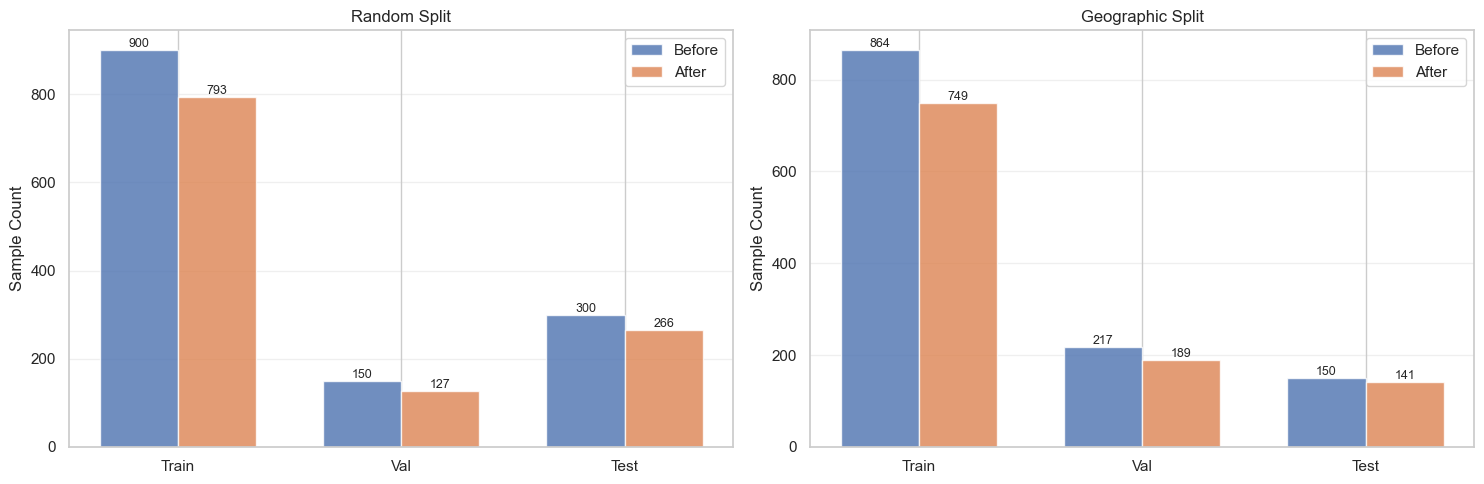

In [15]:
def load_split(split_dir):
    splits = {}
    for phase in ['train', 'val', 'test']:
        f = BASE_DIR / 'splits' / split_dir / f'{phase}.txt'
        with open(f) as file:
            splits[phase] = set(line.strip() for line in file)
    return splits

split_types = ['random', 'geographic']
split_summary = []

for split_type in split_types:
    print(f"\nSplit Analysis: {split_type.capitalize()}")
    
    splits = load_split(split_type)
    
    for phase in ['train', 'val', 'test']:
        phase_ids = splits[phase]
        phase_df = df[df['sample_id'].isin(phase_ids)]
        
        before = len(phase_df)
        after = (phase_df['valid_sample']).sum()
        pct_removed = (1 - after/before) * 100 if before > 0 else 0
        
        print(f"{phase.capitalize():6s} | Before: {before:4d} | After: {after:4d} | Removed: {pct_removed:5.1f}%")
        
        split_summary.append({
            'Split': split_type,
            'Phase': phase,
            'Before': before,
            'After': after,
            'Removed': before - after,
            'Pct Removed': pct_removed
        })

split_df = pd.DataFrame(split_summary)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, split_type in enumerate(split_types):
    data = split_df[split_df['Split'] == split_type]
    ax = axes[idx]
    
    x = np.arange(len(data))
    width = 0.35
    
    ax.bar(x - width/2, data['Before'], width, label='Before', alpha=0.8)
    ax.bar(x + width/2, data['After'], width, label='After', alpha=0.8)
    
    ax.set_ylabel('Sample Count')
    ax.set_title(f'{split_type.capitalize()} Split')
    ax.set_xticks(x)
    ax.set_xticklabels(data['Phase'].str.capitalize())
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    for i, (b, a) in enumerate(zip(data['Before'], data['After'])):
        ax.text(i - width/2, b, str(int(b)), ha='center', va='bottom', fontsize=9)
        ax.text(i + width/2, a, str(int(a)), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Statistics (Before & After Filtering)

The statistics for the threshold-based filtered dataset will be computed and compared to the statistics before filtering.

In [16]:
print("Computing statistics on filtered dataset...")
stats_filtered, _, band_names = compute_stats(df[df['valid_sample']], bands=[0, 1])

stats_df_filtered = pd.DataFrame(stats_filtered).T
stats_df_filtered.index = [band_names[i] for i in stats_df_filtered.index]
stats_df_filtered = stats_df_filtered.round(2)

print("\nOriginal Statistics (all samples):")
display(stats_df)

print("\nFiltered Statistics (valid samples only):")
display(stats_df_filtered)

Computing statistics on filtered dataset...
Using: CPU
  Processed: 100/1196
  Processed: 200/1196
  Processed: 300/1196
  Processed: 400/1196
  Processed: 500/1196
  Processed: 600/1196
  Processed: 700/1196
  Processed: 800/1196
  Processed: 900/1196
  Processed: 1000/1196
  Processed: 1100/1196

Original Statistics (all samples):


,count,mean,std,min,max,median,p1,p5,p25,p50,p75,p95,p99
VV,1.340655e+09,-17.24,24.17,-47.75,21936.06,-27.01,-36.34,-33.75,-29.92,-27.01,0.0,41.23,80.35
VH,1.340655e+09,-24.26,19.72,-49.77,1511.14,-33.16,-40.41,-38.65,-35.64,-33.16,0.0,21.14,29.51



Filtered Statistics (valid samples only):


,count,mean,std,min,max,median,p1,p5,p25,p50,p75,p95,p99
VV,1.243240e+09,-18.10,24.69,-47.75,21936.06,-27.57,-36.36,-33.82,-30.15,-27.57,-24.70,41.23,80.35
VH,1.243240e+09,-25.55,19.53,-49.77,1511.14,-33.75,-40.48,-38.79,-36.00,-33.75,-31.34,21.14,29.51


## Train Set-based Normalization (means/stds for both Splits)

For each split type (random / geographic), the train sets will be used to compute mean and std for further data normalization (values are crucial for the training pipeline).

In [17]:
def get_split_stats(split_type, df, bands=[0, 1]):
    splits = load_split(split_type)
    train_ids = splits['train']
    train_df = df[(df['sample_id'].isin(train_ids)) & (df['valid_sample'])]
    
    print(f"\nComputing stats for {split_type} train set...")
    stats, _, _ = compute_stats(train_df, bands=bands)
    
    means = {band: stats[band]['mean'] for band in bands}
    stds = {band: stats[band]['std'] for band in bands}
    
    print(f"\n  VV: mean={means[0]:.2f} dB, std={stds[0]:.2f} dB")
    print(f"  VH: mean={means[1]:.2f} dB, std={stds[1]:.2f} dB")
    
    return means, stds

split_stats = {}
for split_type in ['random', 'geographic']:
    means, stds = get_split_stats(split_type, df)
    split_stats[split_type] = {'means': means, 'stds': stds}


Computing stats for random train set...
Using: CPU
  Processed: 100/793
  Processed: 200/793
  Processed: 300/793
  Processed: 400/793
  Processed: 500/793
  Processed: 600/793
  Processed: 700/793

  VV: mean=-17.87 dB, std=26.34 dB
  VH: mean=-25.61 dB, std=19.91 dB

Computing stats for geographic train set...
Using: CPU
  Processed: 100/749
  Processed: 200/749
  Processed: 300/749
  Processed: 400/749
  Processed: 500/749
  Processed: 600/749
  Processed: 700/749

  VV: mean=-19.42 dB, std=22.68 dB
  VH: mean=-26.84 dB, std=17.84 dB


## Save Filtered Metadata + Stats

To use the filtered dataset properly in the training pipeline, the filtered metadata is saved as CSV (indexing valid and invalid samples). Moreover, then the split-based statistics (means/stds, and sample counts per split phase) are saved as JSON.

In [30]:
filtered_meta = df[['sample_id', 'label']].copy()

split_info = []

for split_type in ['random', 'geographic']:
    splits = load_split(split_type)

    for phase in ['train', 'val', 'test']:
        for sample_id in splits[phase]:
            split_info.append({'sample_id': sample_id,'split_type': split_type,'phase': phase })

split_df = pd.DataFrame(split_info)
filtered_meta = filtered_meta.merge(split_df,on='sample_id')

validity = df.set_index('sample_id')[['valid_sample', 'nodata_frac']]
filtered_meta = filtered_meta.merge( validity, left_on='sample_id', right_index=True)

export_dir = Path('../30_experiments')
export_dir.mkdir(exist_ok=True)

filtered_meta.to_csv( export_dir / 'filtered_metadata.csv', index=False)
print(f"Saved: {export_dir / 'filtered_metadata.csv'}")

for split_type in ['random', 'geographic']:
    splits = load_split(split_type)
    for phase in ['train', 'val', 'test']:
        phase_ids = splits[phase]
        phase_df = df[ (df['sample_id'].isin(phase_ids)) & (df['valid_sample'])]
        split_stats[split_type][phase] = { 'n_samples': int(len(phase_df)) }

with open(export_dir / 'split_stats.json', 'w') as f:
    json.dump(split_stats, f, indent=2)

print(f"Saved: {export_dir / 'split_stats.json'}")

Saved: ..\30_experiments\filtered_metadata.csv
Saved: ..\30_experiments\split_stats.json


## GeoTIFF Examples

The following examples show positive (oil spill) and negative (non-oil spill) GeoTIFF samples after normalization using the statistics computed from the random training split. Both valid and invalid samples are included to illustrate the diversity and quality of the dataset before model training.

In [ ]:
means = split_stats['random']['means']
stds = split_stats['random']['stds']

all_samples = df[df['image_path'].apply(lambda img_path: get_img_path(img_path).exists())]
valid_samples = all_samples[all_samples['valid_sample']]

pos_samples = valid_samples[valid_samples['label'] == 1].iloc[0:2]
neg_samples = valid_samples[valid_samples['label'] == 0].iloc[0:2]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Valid Samples (non-corrupted TIFFS / nodata_frac <= 40%)', fontsize=14)

for i, (_, row) in enumerate(pos_samples.iterrows()):
    plot_geotiff(row, ax=axes[0, i], title=f"Positive VV | {row['sample_id']}", band=0, mean=means, std=stds)

for i, (_, row) in enumerate(neg_samples.iterrows()):
    plot_geotiff(row, ax=axes[0, 2+i], title=f"Negative VV | {row['sample_id']}", band=0, mean=means, std=stds)

for i, (_, row) in enumerate(pos_samples.iterrows()):
    plot_geotiff(row, ax=axes[1, i], title=f"Positive VH | {row['sample_id']}", band=1, mean=means, std=stds)

for i, (_, row) in enumerate(neg_samples.iterrows()):
    plot_geotiff(row, ax=axes[1, 2+i], title=f"Negative VH | {row['sample_id']}", band=1, mean=means, std=stds)

plt.tight_layout()
plt.show()

In [ ]:
all_samples = df[df['image_path'].apply(lambda img_path: get_img_path(img_path).exists())]
invalid_samples = all_samples[~all_samples['valid_sample']]

pos_samples = invalid_samples[invalid_samples['label'] == 1].iloc[4:6]
neg_samples = invalid_samples[invalid_samples['label'] == 0].iloc[0:2]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Filtered-out Samples (corrupted TIFFS / nodata_frac > 40%)', fontsize=14)

for i, (_, row) in enumerate(pos_samples.iterrows()):
    plot_geotiff(row, ax=axes[0, i], title=f"Positive VV | {row['sample_id']}", band=0, mean=means, std=stds)

for i, (_, row) in enumerate(neg_samples.iterrows()):
    plot_geotiff(row, ax=axes[0, 2+i], title=f"Negative VV | {row['sample_id']}", band=0, mean=means, std=stds)

for i, (_, row) in enumerate(pos_samples.iterrows()):
    plot_geotiff(row, ax=axes[1, i], title=f"Positive VH | {row['sample_id']}", band=1, mean=means, std=stds)

for i, (_, row) in enumerate(neg_samples.iterrows()):
    plot_geotiff(row, ax=axes[1, 2+i], title=f"Negative VH | {row['sample_id']}", band=1, mean=means, std=stds)

plt.tight_layout()
plt.show()